# GP-PHS: Inverted Pendulum on a Cart, Non-Separable Hamiltonian

### A 4-State Underactuated Port-Hamiltonian System with a Configuration-Dependent Mass Matrix

The Hamiltonian of the system is

$$
H(q_1,q_2,p_1,p_2)
=
\frac{1}{2} p^T M(q_2)^{-1} p
-
mg\ell\cos q_2
$$

where

$$
M(q_2) = \begin{bmatrix} M_c+m & m\ell\cos q_2 \\ m\ell\cos q_2 & m\ell^2\end{bmatrix}
$$

- $q_1$ is the cart position, $q_2 = \theta$ is the pendulum angle (measured from hanging equilibrium),
- $p_1, p_2$ are the generalized momenta, $p = M(q_2)\dot q$,
- $M_c$ is the cart mass, $m$ is the pendulum bob mass, $\ell$ is the pendulum length,
- $g$ is gravitational acceleration.

## Mathematical Formulation

### Interconnection Matrix (Constant — Canonical Symplectic)
$$
J = \begin{bmatrix}
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1 \\
-1 & 0 & 0 & 0 \\
0 & -1 & 0 & 0
\end{bmatrix}
$$

Check: $J^T = -J$ (skew-symmetric) 

### Dissipation Matrix (Constant & PSD)
$$
R = \begin{bmatrix}
0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 \\
0 & 0 & b_1 & 0 \\
0 & 0 & 0 & b_2
\end{bmatrix}
$$

### Input Matrix (Underactuated)
$$
G = \begin{bmatrix}
0 \\
0 \\
1 \\
0
\end{bmatrix}
$$

Force enters only through the cart's momentum row, the pendulum row is zero, so $\dot p_2$ must be explained entirely by the learned $J\nabla H$ term.

### Complete Dynamics
$$
\dot{x} = (J - R)\nabla H(x) + Gu
$$

### Parameters to Learn
$$
\theta = \{b_1, b_2\} \quad \text{(2 parameters: deliberately minimal, since } H \text{ is the target under test)}
$$

### Install (Colab only)
Skip this step when running locally.

In [1]:
# ── Google Colab / fresh environment setup ──────────────────────────────────
# !pip install -q git+https://github.com/essey1/neuromancer.git gpytorch scipy

## Imports

In [2]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parents[1] / "src"))

import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
import gpytorch
from scipy.integrate import odeint
from torch.utils.data import DataLoader

from neuromancer import psl
from neuromancer import dataset
import neuromancer.dataset as dataset
from neuromancer.psl import plot
from neuromancer.dynamics import gp_phs, ode
from neuromancer.psl import gp_smoother
from neuromancer.modules import hamiltonian_approximator
from neuromancer.system import Node, System
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.loss import AugmentedLagrangeLoss
from neuromancer.problem import Problem
from neuromancer.trainer import Trainer
from neuromancer.loggers import BasicLogger

torch.manual_seed(0); np.random.seed(0)

## Configuration

In [3]:
# ============================================================
# DATA & TRAINING HYPERPARAMETERS
# ============================================================
N_POINTS = 150         # per trajectory; total = N_POINTS * len(X0_TRAIN)
NOISE    = 0.001       # sensor noise std
N_EPOCHS = 2000
NX, NU   = 4, 1        # NU=1: underactuated — force enters the cart row only
T_SIM    = 3.5

X0_TRAIN = [
    [0.00, 0.20, 0.00, 0.00],
    [0.20, 0.00, 0.00, 0.00],
    [0.00, 0.00, 0.10, 0.00],
    [0.00, 0.00, 0.00, 0.10],
    [0.15, 0.15, 0.05, 0.05],
    [-0.15, 0.15, -0.05, 0.05],
]

X0_TEST = [
    [0.02, 0.22, 0.01, 0.00],     # near pendulum displacement
    [0.22, 0.02, 0.01, 0.01],     # near cart displacement
    [0.01, 0.01, 0.11, 0.01],     # near cart momentum
    [0.01, 0.01, 0.01, 0.11],     # near pendulum momentum
    [0.16, 0.16, 0.06, 0.05],     # near coupled excitation
    [-0.12, 0.12, -0.04, 0.06],   # near sign-mixed coupling
]

# ============================================================
# TRUE SYSTEM PARAMETERS
# ============================================================

# Cart, pendulum mass/length, gravity
MC_TRUE = 1.0
M_TRUE  = 0.3        # heavier pendulum
L_TRUE  = 1.0        # longer pendulum
G_TRUE  = 9.81

# Dissipation
B1_TRUE = 0.10       # cart viscous friction
B2_TRUE = 0.05       # pivot friction

# Input signal
INPUT_AMP    = 0.3
INPUT_FREQ_A = 0.3
INPUT_FREQ_B = 0.9

# per-trajectory frequency, replacing the two fixed constants
omega_pend = np.sqrt(G_TRUE / L_TRUE)
DRIVE_FREQS_A = np.linspace(0.5 * omega_pend, 1.2 * omega_pend, len(X0_TRAIN))
DRIVE_FREQS_B = np.linspace(1.5 * omega_pend, 2.5 * omega_pend, len(X0_TRAIN))

## True System

In [4]:
# Define true system parameters
true_params = {
    'Mc': MC_TRUE, 'm': M_TRUE, 'l': L_TRUE, 'g': G_TRUE,
    'b1': B1_TRUE, 'b2': B2_TRUE
}

def mass_matrix(q2):
    """Configuration-dependent mass matrix M(q2)"""
    return np.array([
        [MC_TRUE + M_TRUE,              M_TRUE * L_TRUE * np.cos(q2)],
        [M_TRUE * L_TRUE * np.cos(q2),  M_TRUE * L_TRUE**2          ]
    ])

def mass_matrix_dq2(q2):
    """Derivative of M(q2) with respect to q2"""
    return np.array([
        [0.0,                          -M_TRUE * L_TRUE * np.sin(q2)],
        [-M_TRUE * L_TRUE * np.sin(q2), 0.0                         ]
    ])

def H_true(q1, q2, p1, p2):
    """Hamiltonian energy"""
    M = mass_matrix(q2)
    p = np.array([p1, p2])
    M_inv = np.linalg.inv(M)
    return 0.5 * p @ M_inv @ p - M_TRUE * G_TRUE * L_TRUE * np.cos(q2)

def grad_H_true(state):
    """Gradient of Hamiltonian"""
    q1, q2, p1, p2 = state
    p = np.array([p1, p2])
    M     = mass_matrix(q2)
    M_inv = np.linalg.inv(M)
    dM    = mass_matrix_dq2(q2)

    dH_dq1 = 0.0
    dH_dq2 = -0.5 * (p @ M_inv @ dM @ M_inv @ p) + M_TRUE * G_TRUE * L_TRUE * np.sin(q2)
    dH_dp  = M_inv @ p

    return np.array([dH_dq1, dH_dq2, dH_dp[0], dH_dp[1]])

def J_true(state):
    """Skew-symmetric interconnection matrix J (constant)"""
    return np.array([
        [0,   0,   1,   0],
        [0,   0,   0,   1],
        [-1,  0,   0,   0],
        [0,  -1,   0,   0]
    ])

def R_true(state):
    """Dissipation matrix R [diagonal, constant]"""
    return np.diag([
        0.0,
        0.0,
        B1_TRUE,
        B2_TRUE
    ])

def G_mat_true(state):
    """Input matrix G (constant, underactuated)"""
    return np.array([
        [0.0],
        [0.0],
        [1.0],
        [0.0]
    ])

def input_signal(t, freq_a, freq_b):
    """Time-dependent input signal u(t) for a given trajectory's drive frequencies"""
    u1 = INPUT_AMP * np.sin(freq_a * t) + 0.6 * np.sin(freq_b * t)
    return np.array([u1])

def dynamics(state, t, sig=input_signal):
    """Complete PHS dynamics: ẋ = (J-R)∇H + Gu"""
    grad_h = grad_H_true(state)
    J = J_true(state)
    R = R_true(state)
    G = G_mat_true(state)
    u = sig(t)
    return (J - R) @ grad_h + G @ u

### Plot

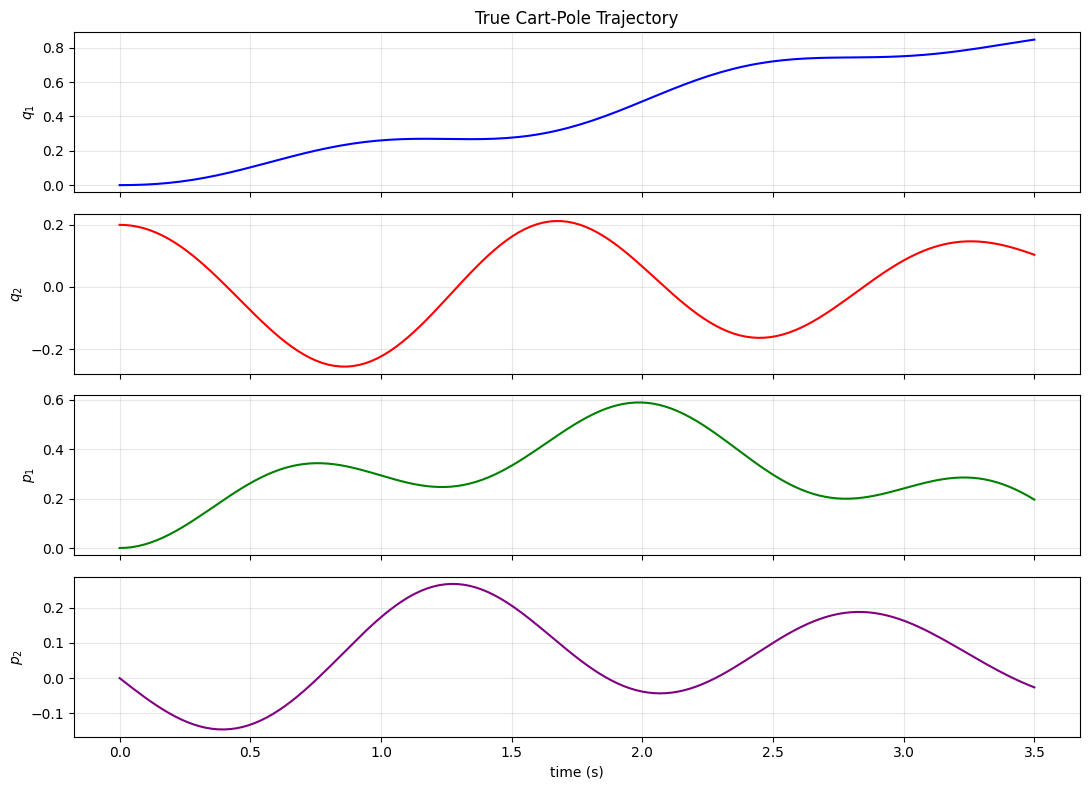

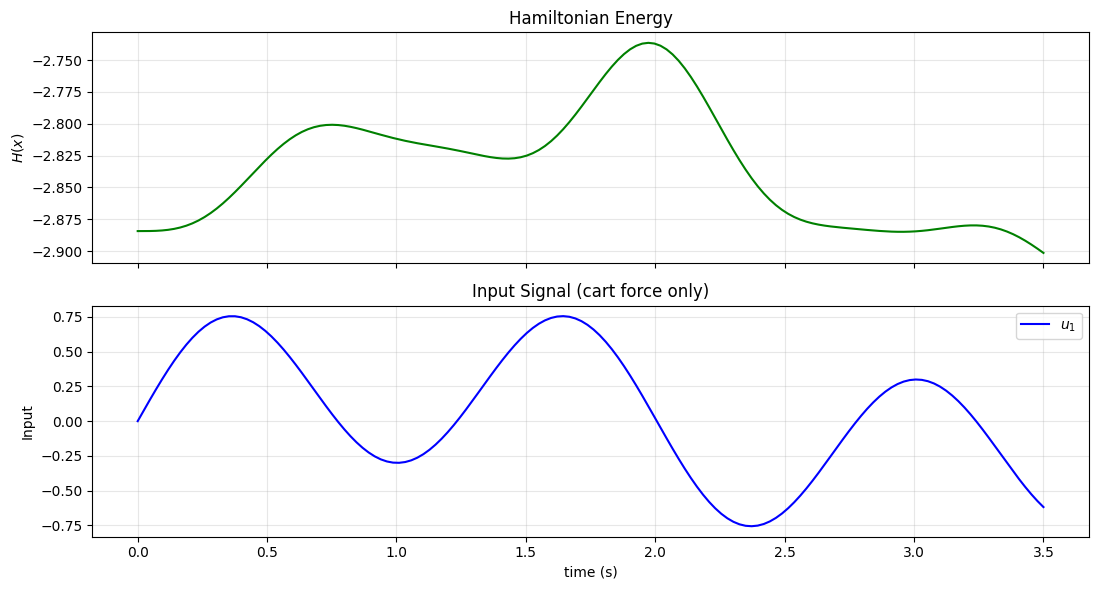

In [5]:
# Plot the large-swing trajectory (trajectory 2 — largest q2 excursion)
i = 0
x0  = X0_TRAIN[i]
t_i = np.linspace(0, T_SIM, N_POINTS)
fa, fb = DRIVE_FREQS_A[i], DRIVE_FREQS_B[i]
sig = lambda t, fa=fa, fb=fb: input_signal(t, fa, fb)

traj_i = odeint(lambda state, t, s=sig: dynamics(state, t, s), x0, t_i)
u_i    = np.array([sig(t) for t in t_i])
H_i    = np.array([H_true(x[0], x[1], x[2], x[3]) for x in traj_i])

fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
labels = [r'$q_1$', r'$q_2$', r'$p_1$', r'$p_2$']
colors = ['b', 'r', 'g', 'purple']
for j, (ax, lbl, col) in enumerate(zip(axes, labels, colors)):
    ax.plot(t_i, traj_i[:, j], col, lw=1.5)
    ax.set_ylabel(lbl); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('time (s)')
axes[0].set_title('True Cart-Pole Trajectory')
plt.tight_layout(); plt.show()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax1.plot(t_i, H_i, 'g', lw=1.5)
ax1.set_ylabel(r'$H(x)$'); ax1.grid(True, alpha=0.3)
ax1.set_title('Hamiltonian Energy')
ax2.plot(t_i, u_i[:, 0], 'b', label=r'$u_1$', lw=1.5)
ax2.set_ylabel('Input'); ax2.set_xlabel('time (s)'); ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_title('Input Signal (cart force only)')
plt.tight_layout(); plt.show()

## Step 1: Dataset Preparation

### Data Sampling & Dataset Preparation

Simulate trajectories from multiple initial conditions, add sensor noise, and apply GP smoothing to estimate derivatives $\dot{x}$ and their uncertainty $\Delta$. The result is split into train/dev/test DataLoaders ready for training.

In [6]:
# DATA GENERATION
sigs = [
    (lambda t, fa=fa, fb=fb: input_signal(t, fa, fb))
    for fa, fb in zip(DRIVE_FREQS_A, DRIVE_FREQS_B)
]
trajs_true, trajs, us, t_all = [], [], [], []
for i, (x0, sig) in enumerate(zip(X0_TRAIN, sigs)):
    t_i = np.linspace(i * T_SIM, (i + 1) * T_SIM, N_POINTS)
    x_i = odeint(lambda state, t, s=sig: dynamics(state, t, s), x0, t_i)
    u_i = np.array([sig(t) for t in t_i])
    trajs_true.append(x_i)
    x_noisy_i = x_i + np.random.normal(0, NOISE, x_i.shape)
    trajs.append(x_noisy_i); us.append(u_i); t_all.append(t_i)

# GP SMOOTHER
smoothed, xdots, xdot_vars = [], [], []
for t_i, x_i in zip(t_all, trajs):
    x_s, xd, xdv = gp_smoother.gp_smooth(t_i, x_i)
    smoothed.append(x_s); xdots.append(xd); xdot_vars.append(xdv)

# DATA LOADERS
train_loader, dev_loader, test_loader = dataset.get_gpphs_dataloaders(
    x=np.concatenate(smoothed),
    x_dot=np.concatenate(xdots),
    u=np.concatenate(us),
    x_dot_var=np.concatenate(xdot_vars),
    split_ratio=[75.0, 15.0, 10.0],
    batch_size=len(X0_TRAIN) * N_POINTS,
)

C:\Users\arayae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\_compile.py:54: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)
C:\Users\arayae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gpytorch\models\exact_gp.py:299: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


### Plot

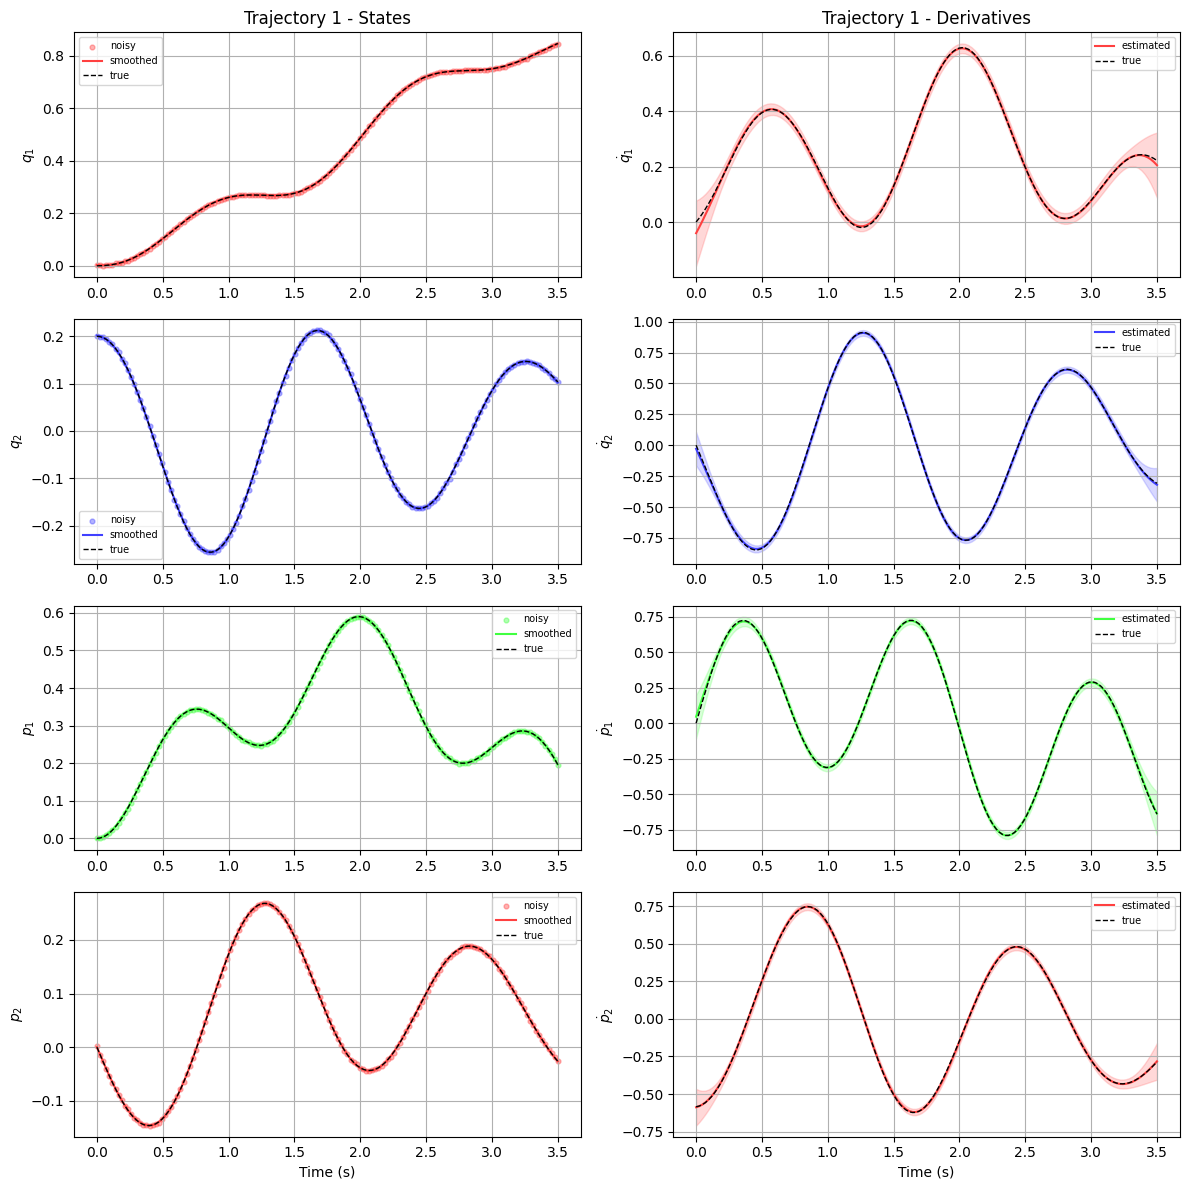

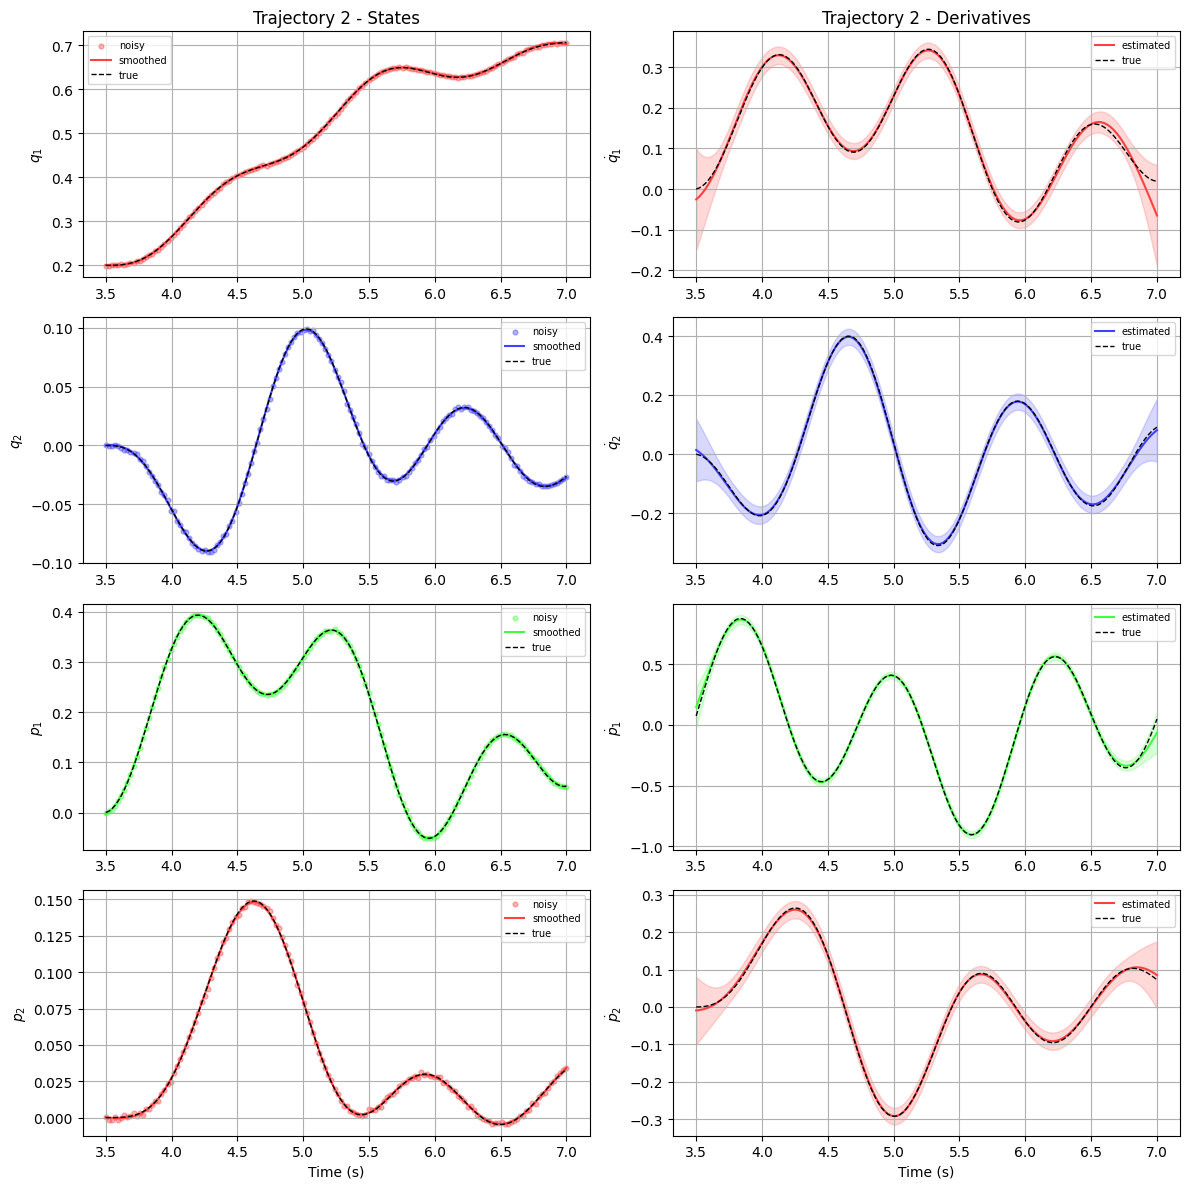

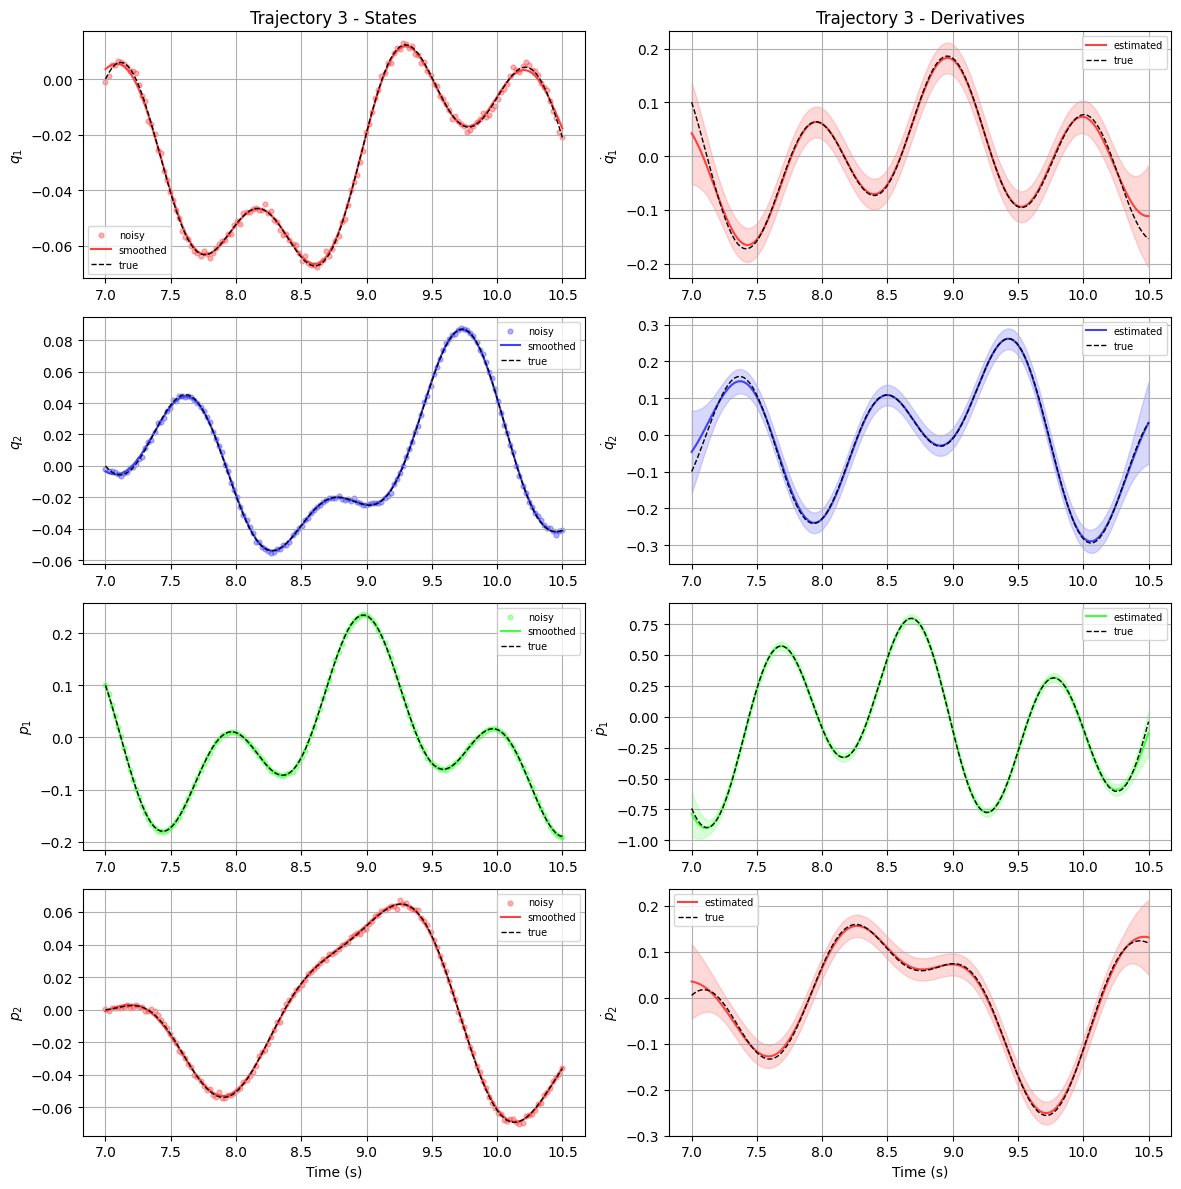

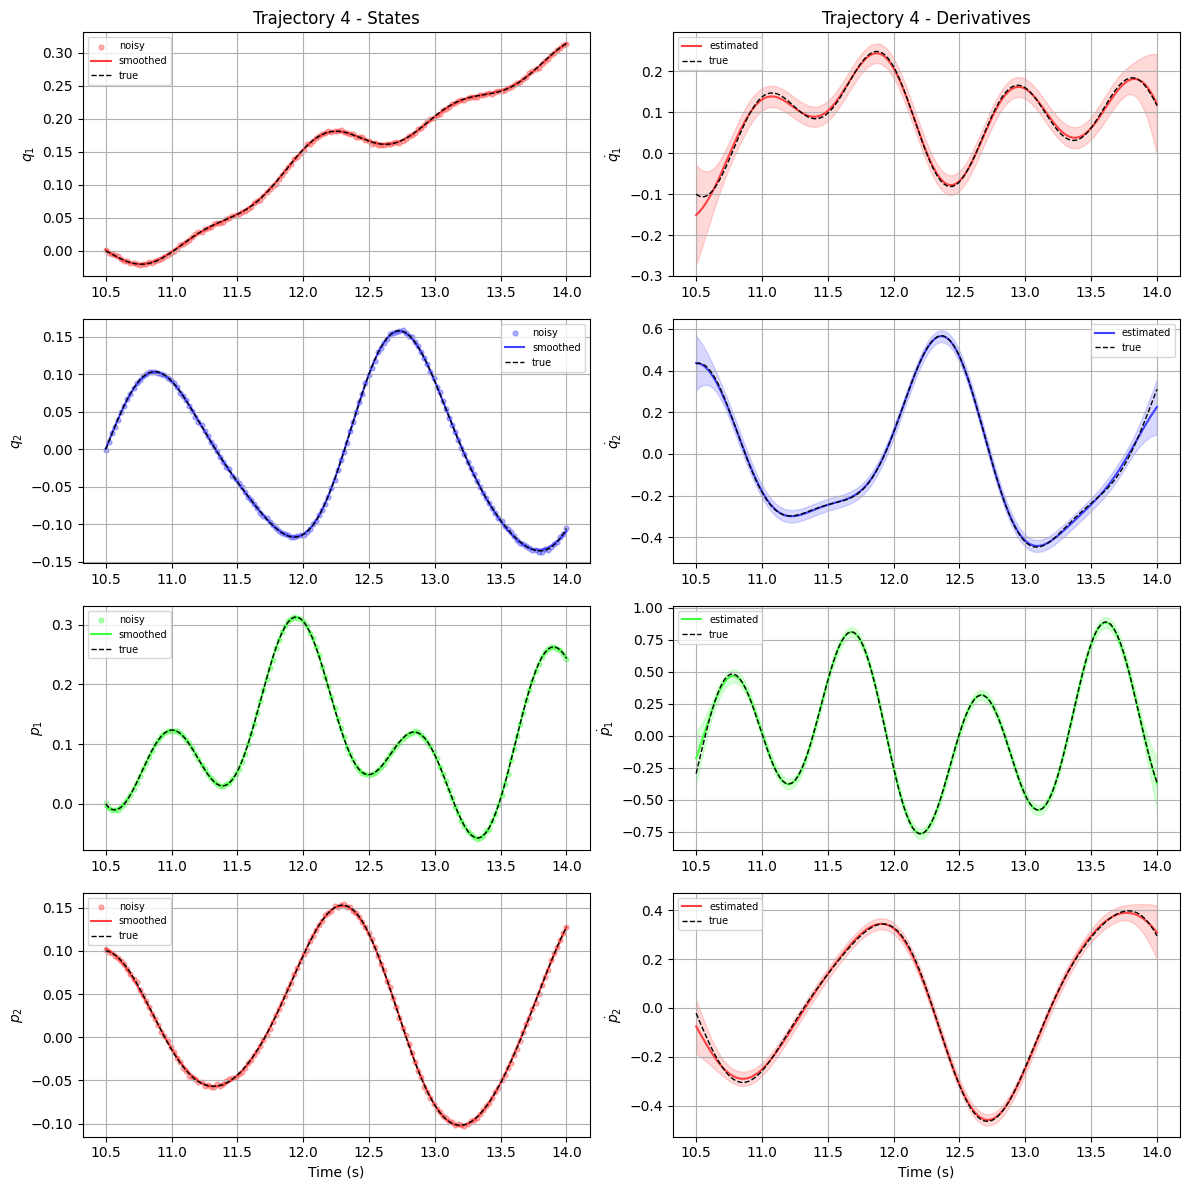

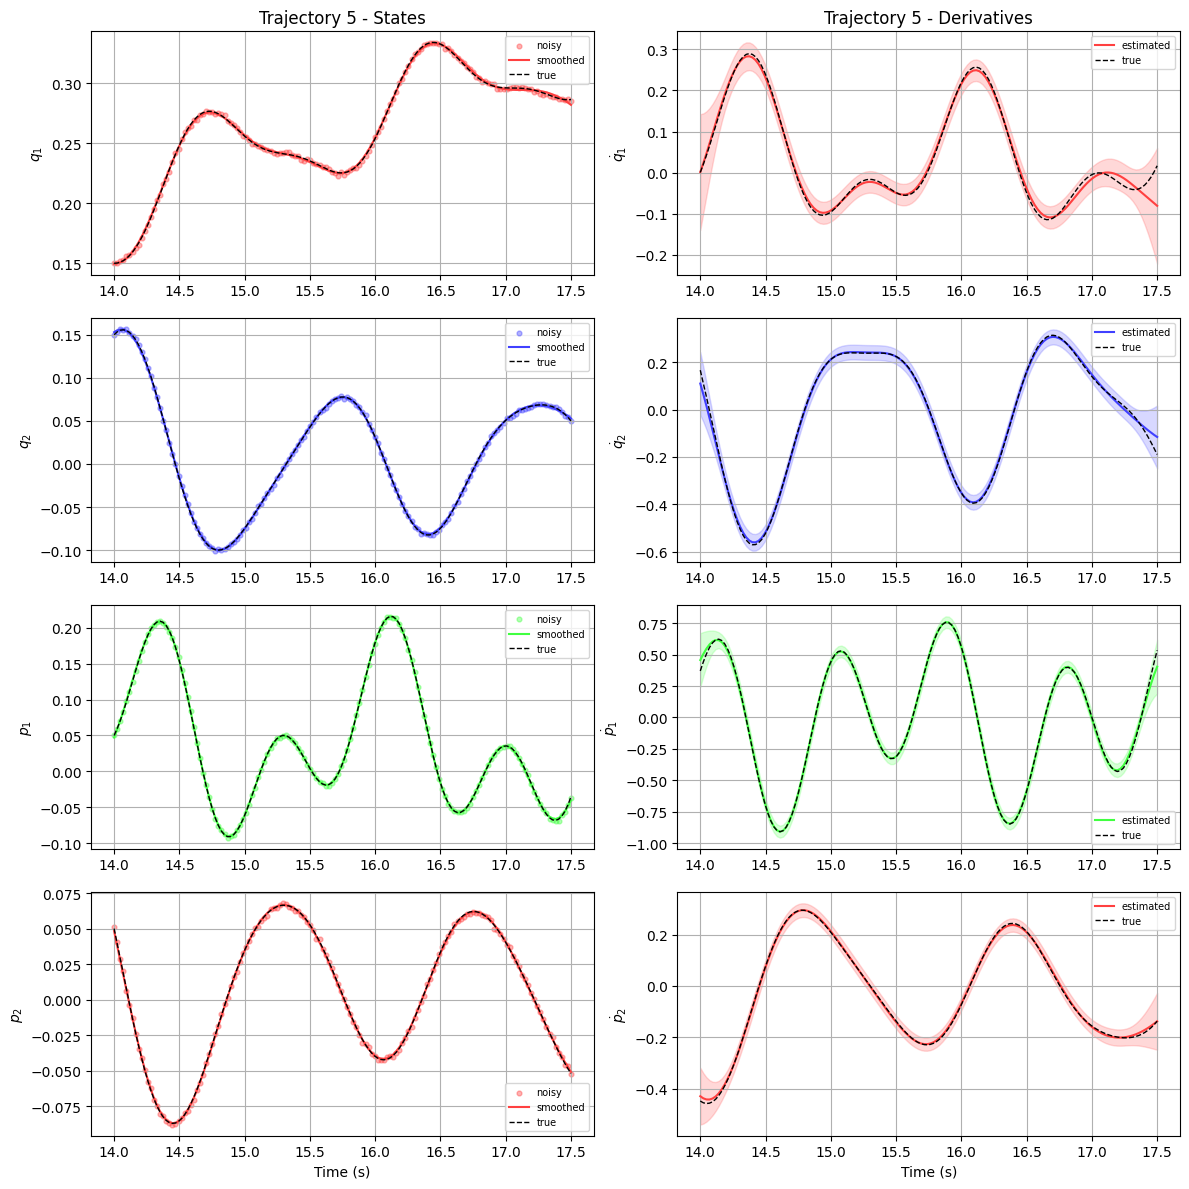

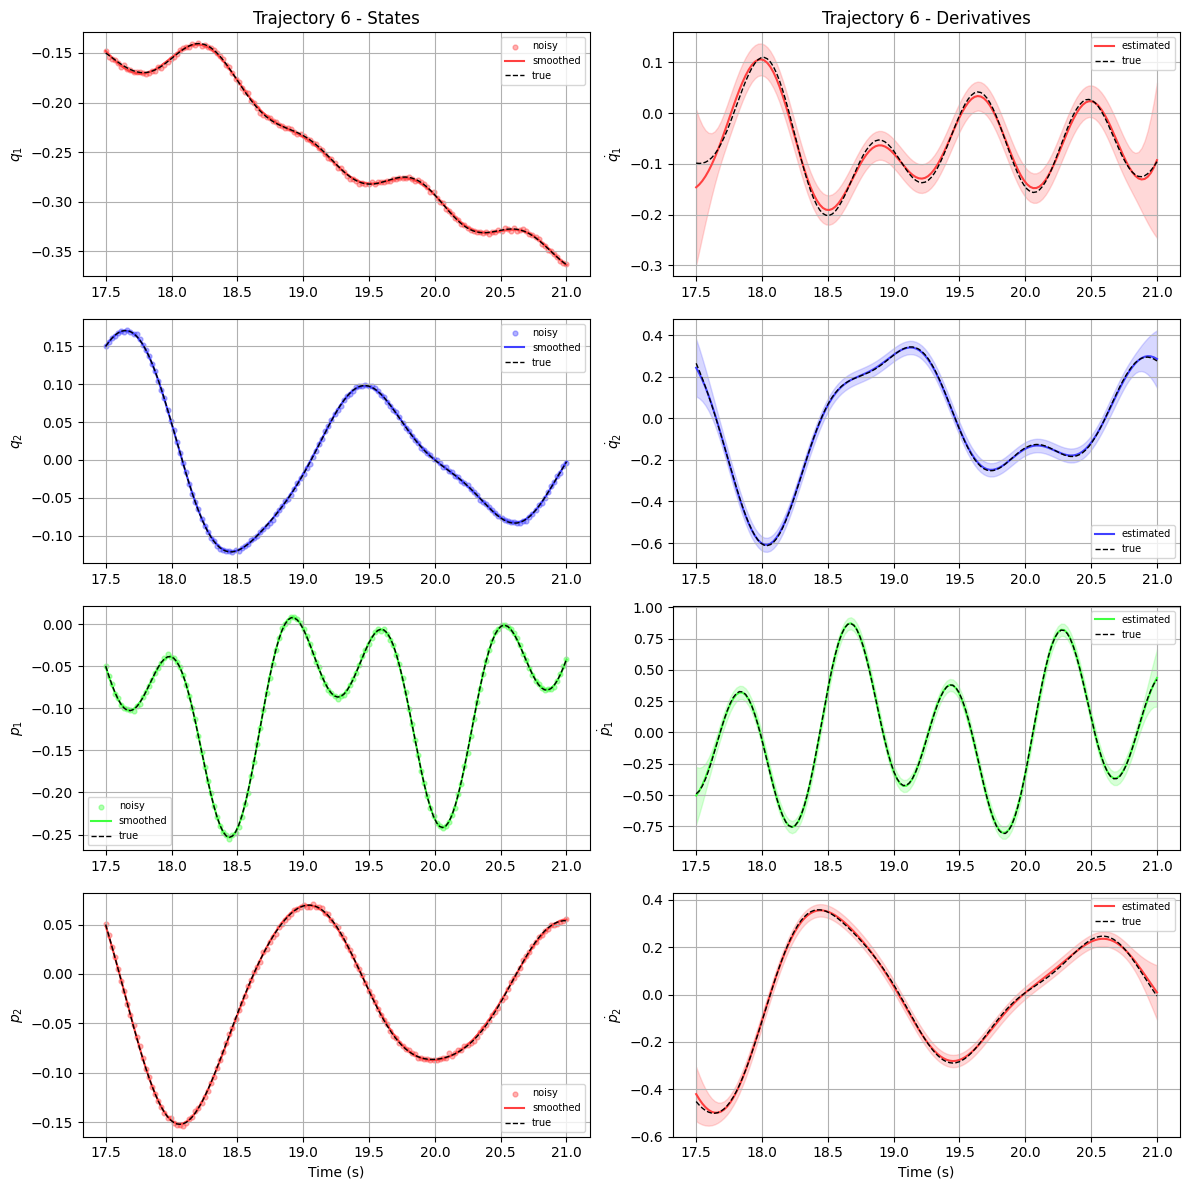

In [7]:
plot.pltGPSmooth(
    t_all,
    trajs,
    smoothed,
    xdots,
    xdot_vars,
    x_trues=trajs_true,
    dynamics=dynamics,
    sigs=sigs,
    state_lbls=[r'$q_1$', r'$q_2$', r'$p_1$', r'$p_2$'],
    deriv_lbls=[r'$\dot{q}_1$', r'$\dot{q}_2$', r'$\dot{p}_1$', r'$\dot{p}_2$'],
)

## Step 2: PHS Structure

In [8]:
b1    = variable(torch.tensor([0.1], requires_grad=True), display_name='b1')
b2    = variable(torch.tensor([0.1], requires_grad=True), display_name='b2')

### Construct PHSMatrices

In [9]:
phs = gp_phs.PHSMatrices(
    nx=NX, nu=NU,
    J_upper={
        (0, 2): lambda x: torch.ones(x.shape[0]),
        (1, 3): lambda x: torch.ones(x.shape[0])
    },
    R_diag={
        0: lambda x: torch.zeros(x.shape[0]),
        1: lambda x: torch.zeros(x.shape[0]),
        2: lambda x: b1.value * torch.ones(x.shape[0]),
        3: lambda x: b2.value * torch.ones(x.shape[0])
    },
    G_full={
        (2, 0): lambda x: torch.ones(x.shape[0])
    }
)

## Step 3: Build Node, Loss, and Problem

In [10]:
# Build node
gpphs_module = gp_phs.GPPHSNode(phs, NX, NU)
gpphs_node = Node(gpphs_module, ['X', 'U', 'Xdot', 'Xdot_var'], ['nlml'], name='gp_phs')

# Objective
nlml = variable('nlml')
nlml_loss = nlml.minimize()
nlml_loss.name = 'nlml_loss'

# Aggregate and build problem
objectives  = [nlml_loss]
constraints = []

loss    = PenaltyLoss(objectives, constraints)
problem = Problem([gpphs_node], loss)

## Step 4: Training

In [11]:
optimizer = torch.optim.Adam(problem.parameters(), lr=0.001)
logger    = BasicLogger(args=None, savedir='test', verbosity=1,
                        stdout=['train_loss', 'dev_loss'])
trainer   = Trainer(
    problem,
    train_loader,
    dev_loader,
    optimizer,
    epochs=N_EPOCHS,
    patience=N_EPOCHS,
    epoch_verbose=5,
    train_metric='train_loss',
    dev_metric='dev_loss',
    eval_metric='dev_loss',
    logger=logger,
)

None
Number of parameters: 8


In [12]:
# train
best_model = trainer.train()
problem.load_state_dict(best_model)

epoch: 0	train_loss: 32455.44336	dev_loss: 61.51550	eltime:  0.62411
epoch: 1	train_loss: 31772.37695	dev_loss: 26.93799	eltime:  1.22520
epoch: 2	train_loss: 31080.19727	dev_loss: -6.97803	eltime:  1.83238
epoch: 3	train_loss: 30413.59961	dev_loss: -40.71875	eltime:  2.45793
epoch: 4	train_loss: 29747.66016	dev_loss: -73.25549	eltime:  3.01636
epoch: 5	train_loss: 29051.33789	dev_loss: -105.56299	eltime:  3.61148
epoch: 6	train_loss: 28389.68555	dev_loss: -137.43115	eltime:  4.14858
epoch: 7	train_loss: 27735.17383	dev_loss: -168.42456	eltime:  4.70282
epoch: 8	train_loss: 27090.07227	dev_loss: -198.91138	eltime:  5.34691
epoch: 9	train_loss: 26456.66992	dev_loss: -228.65283	eltime:  5.97371
epoch: 10	train_loss: 25830.16992	dev_loss: -258.09888	eltime:  6.54133
epoch: 11	train_loss: 25201.39258	dev_loss: -287.29590	eltime:  7.14456
epoch: 12	train_loss: 24566.82617	dev_loss: -315.27490	eltime:  7.70014
epoch: 13	train_loss: 23947.87695	dev_loss: -343.05640	eltime:  8.32283
epoch: 14	

<All keys matched successfully>

### Parameter Recovery

In [13]:
gp_phs.param_table({
    'b₁': (b1, B1_TRUE),
    'b₂': (b2, B2_TRUE),
})

Parameter  True  Learned  Rel. Error %
       b₁  0.10 0.094887      5.113080
       b₂  0.05 0.050225      0.450917

Mean relative error:   2.78%
Median relative error: 2.78%


,Parameter,True,Learned,Rel. Error %
0,b₁,0.10,0.094887,5.113080
1,b₂,0.05,0.050225,0.450917


## Step 5: Hamiltonian Posterior

$H$ is identifiable up to an additive constant; the posterior mean is aligned to the true $H$ at training points.

### Compute posterior

In [14]:
# BUILD GP POSTERIOR
posterior = gpphs_node.callable.posterior()

# COMPUTE HAMILTONIAN POSTERIOR — all trajectories
H_mean, H_var, H_samples = posterior.predict(
    smoothed,
    us,
    xdots,
    xdot_vars,
    n_samples=50,
)

# Concatenate all trajectories for evaluation
x_all      = np.concatenate(smoothed, axis=0)
u_all      = np.concatenate(us, axis=0)
xdot_true  = np.concatenate(xdots, axis=0)
x_all_t    = torch.tensor(x_all, dtype=torch.float32)

# TRUE HAMILTONIAN — all trajectories
H_true_all = np.array([H_true(*row) for row in x_all])

### Plot Hamiltonian posterior

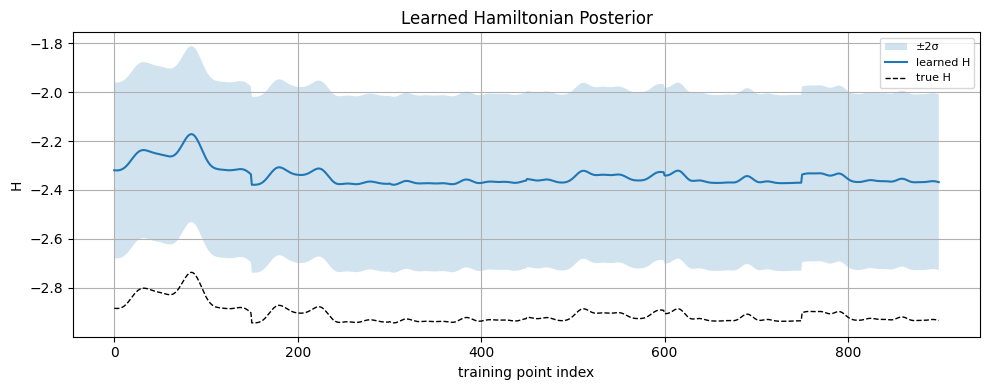

In [15]:
plot.pltHamiltonian(H_mean.numpy(), H_var.numpy(), H_true=H_true_all)

## Step 6: Callable $H^*$ Ensemble

Fit a GP interpolant to each posterior sample so $H^*$ can be evaluated and differentiated anywhere.

In [16]:
ensemble = [
    hamiltonian_approximator.HamiltonianApproximator(
        method='gp',
        lengthscale=posterior.lengthscale,
        signal_var=posterior.signal_var,
    ).fit(x_all_t, H_samples[i])
    for i in range(H_samples.shape[0])
]

## Step 7: Derivative Prediction

Verify that the learned model predicts $\dot{x} = (J(x) - R(x))\nabla H^*(x)$ correctly at training points before committing to full trajectory rollout.

In [17]:
# EVALUATE LEARNED DYNAMICS: ẋ = (J(x) - R(x))∇H*(x) + G(x)u
JR            = (phs.get_J(x_all_t) - phs.get_R(x_all_t)).detach().numpy()
G             = phs.get_G(x_all_t).detach().numpy()
grad_H_stack  = torch.stack([h.gradient(x_all_t) for h in ensemble])
grad_H_mean   = grad_H_stack.mean(0).detach().numpy()
grad_H_std    = grad_H_stack.std(0).detach().numpy()
xdot_pred     = np.einsum('nij,nj->ni', JR, grad_H_mean) + np.einsum('nij,nj->ni', G, u_all)
xdot_pred_std = np.einsum('nij,nj->ni', JR, grad_H_std)

### Plot

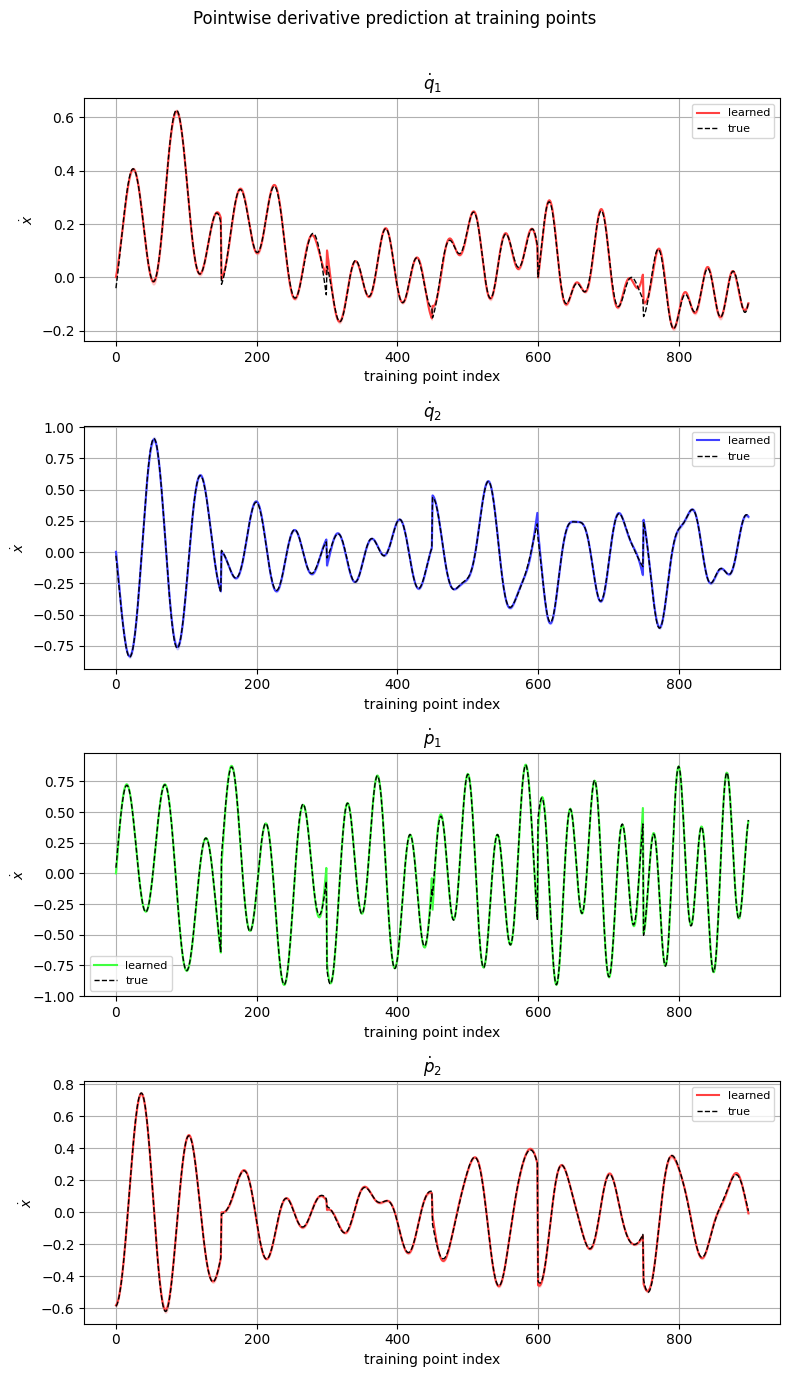

In [18]:
plot.pltXdot(
    xdot_pred, xdot_true,
    xdot_std=xdot_pred_std,
    state_lbls=[r'$\dot{q}_1$', r'$\dot{q}_2$', r'$\dot{p}_1$', r'$\dot{p}_2$'],
)

## Step 8: Trajectory Prediction

Simulate trajectories (one per $H^*$ sample). Shaded band = $\pm 2$ std across the ensemble.

In [19]:
dt    = 0.005
t_sim = np.arange(0.0, T_SIM + dt, dt)

# representative test frequencies — midpoint of training range
fa_test = DRIVE_FREQS_A.mean()
fb_test = DRIVE_FREQS_B.mean()
sig_test = lambda t, fa=fa_test, fb=fb_test: input_signal(t, fa, fb)

u_sim = torch.tensor(
    np.array([sig_test(t) for t in t_sim]),
    dtype=torch.float32,
).unsqueeze(1)

# True reference trajectories — all initial conditions
traj_sims = [
    odeint(lambda state, t: dynamics(state, t, sig_test), x0, t_sim)
    for x0 in X0_TEST
]

# Simulate learned GP-PHS from all initial conditions
phsode = ode.PHSODE(phs, ensemble, NX, NU, method='rk4')
with torch.no_grad():
    result = phsode.simulate(
        x0=torch.tensor(X0_TEST, dtype=torch.float32),
        t_span=(0.0, T_SIM),
        u=u_sim.expand(-1, len(X0_TEST), -1),
        dt=dt,
    )

t_gp = result['t_eval'].numpy()
mean = result['mean'].numpy()   # (T, N, nx)
std  = result['std'].numpy()    # (T, N, nx)

### Plot trajectory prediction

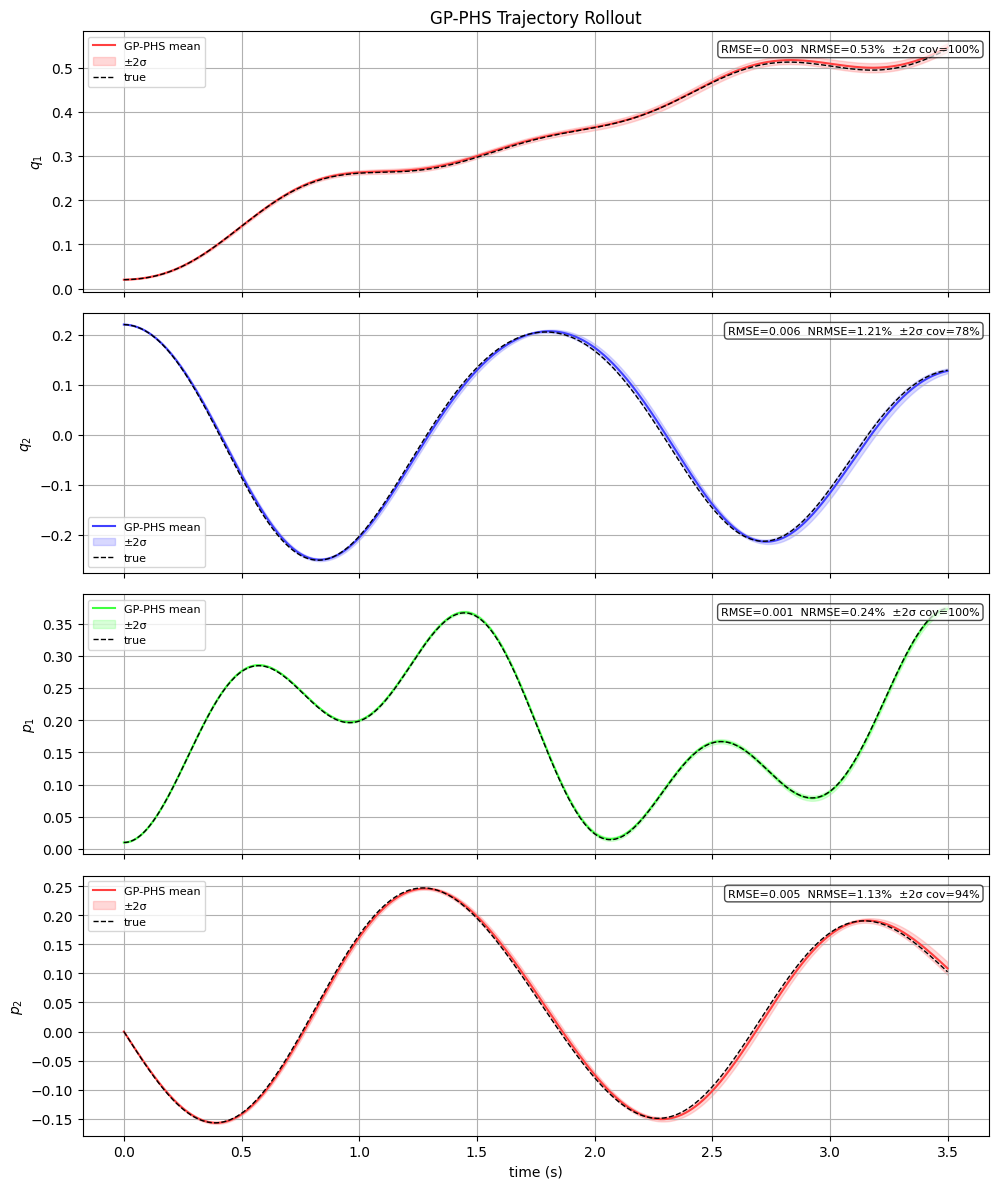

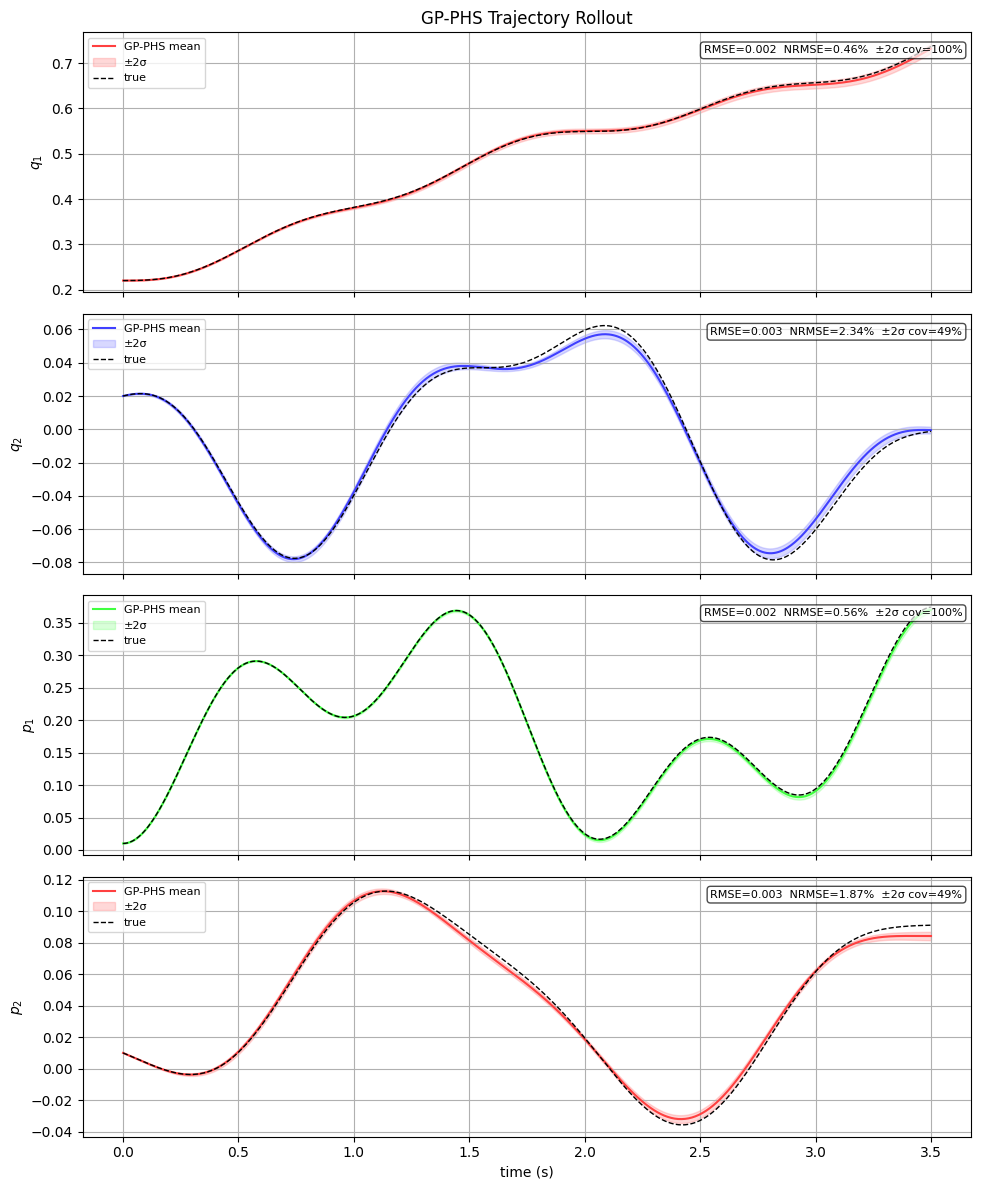

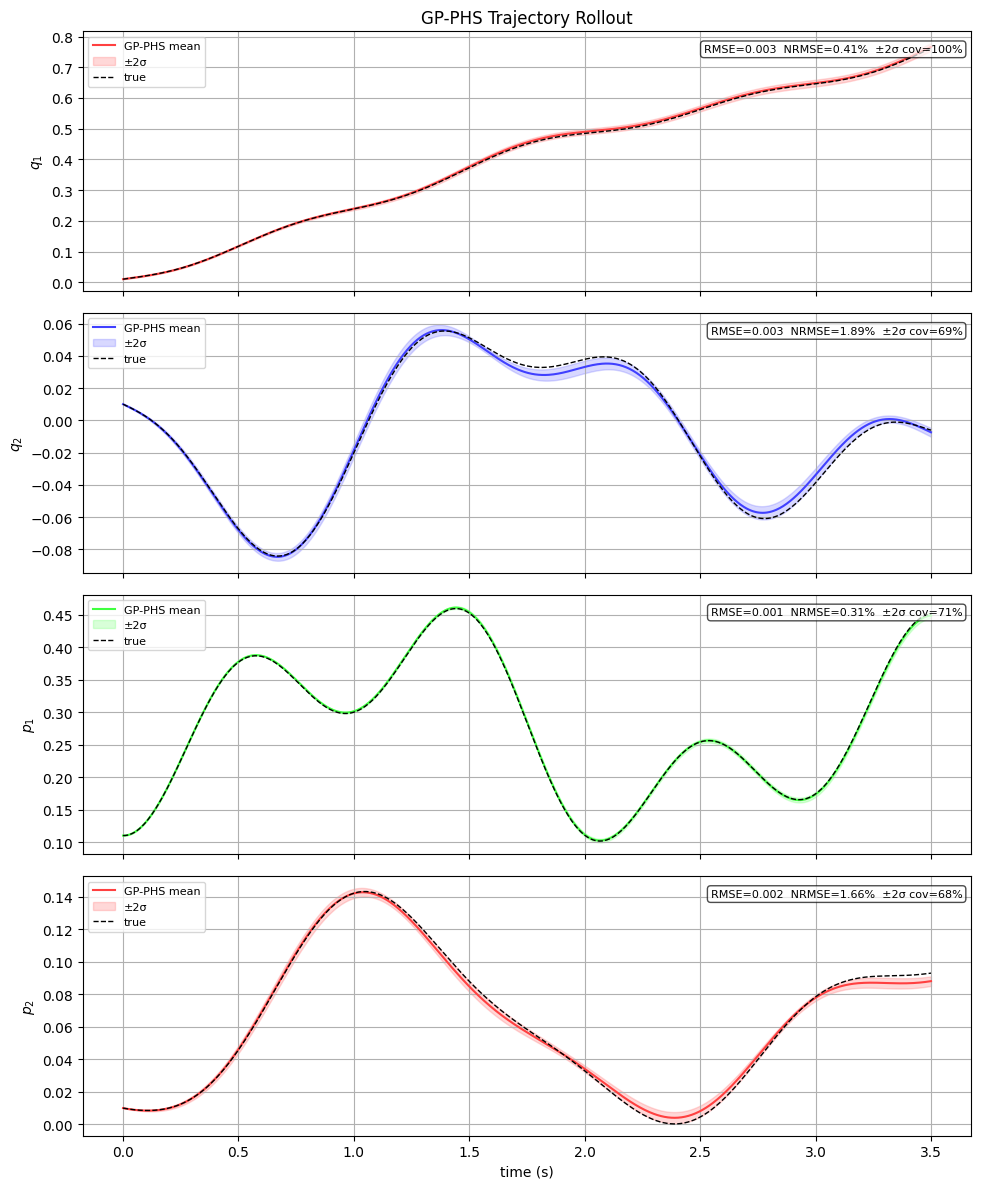

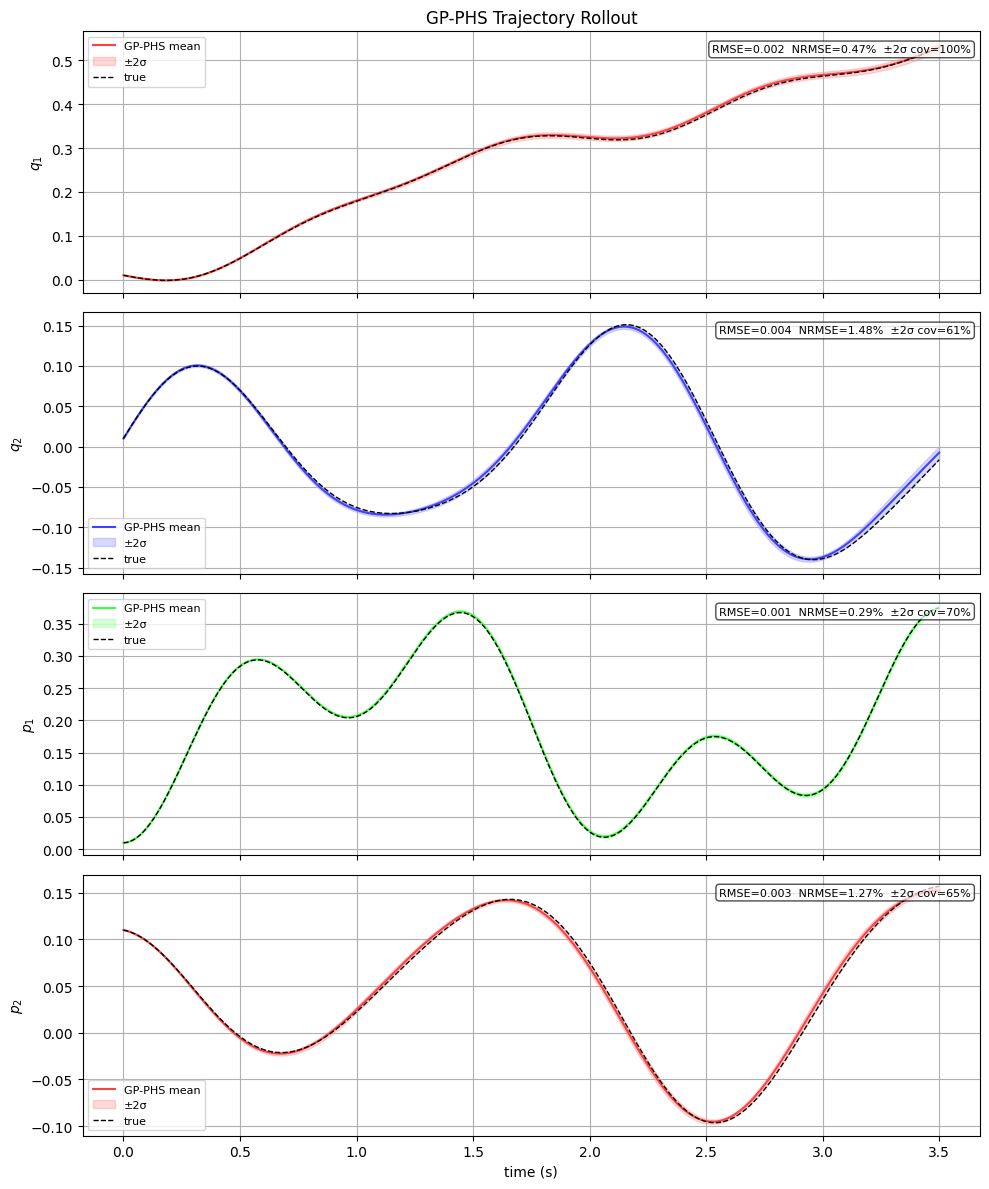

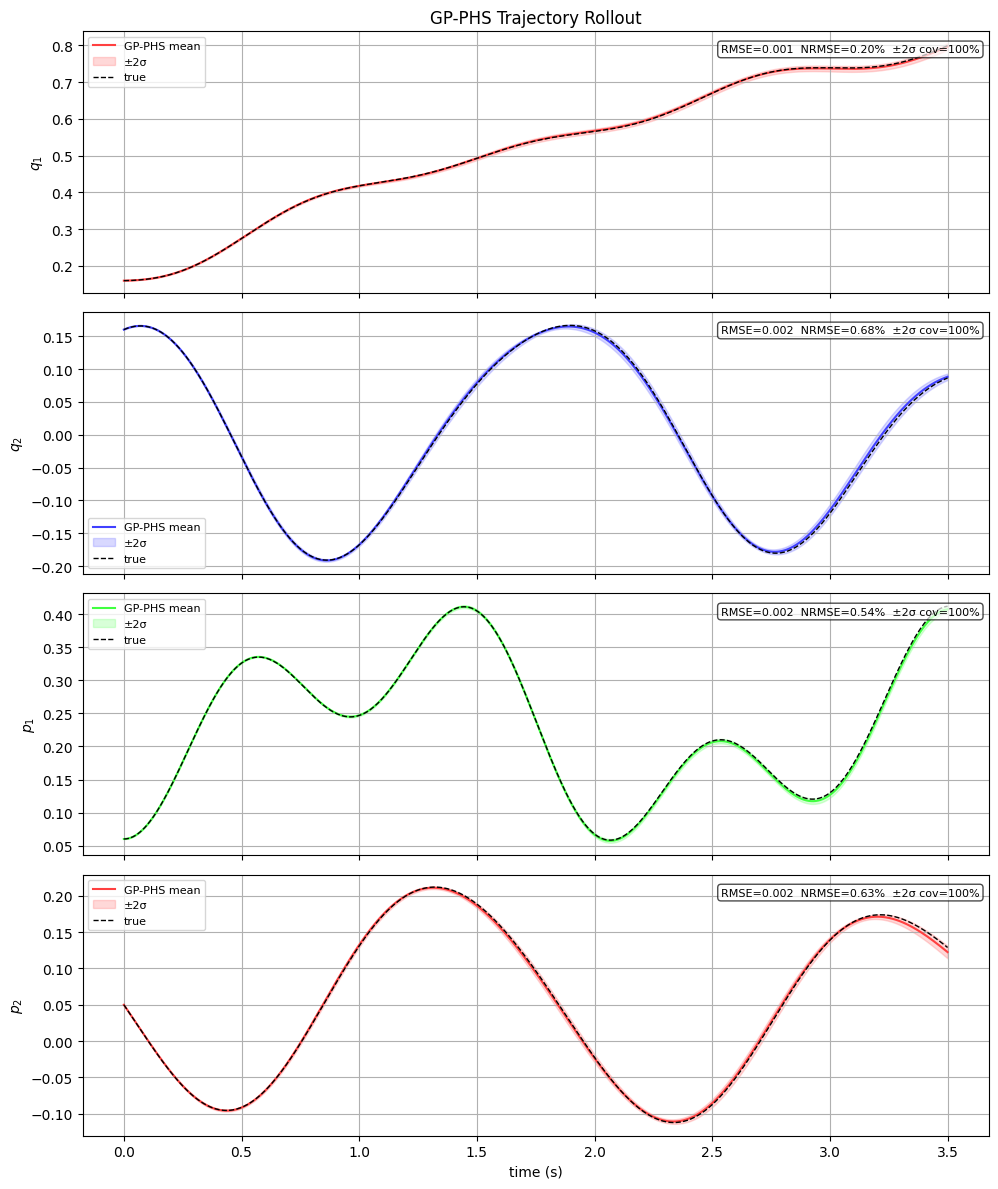

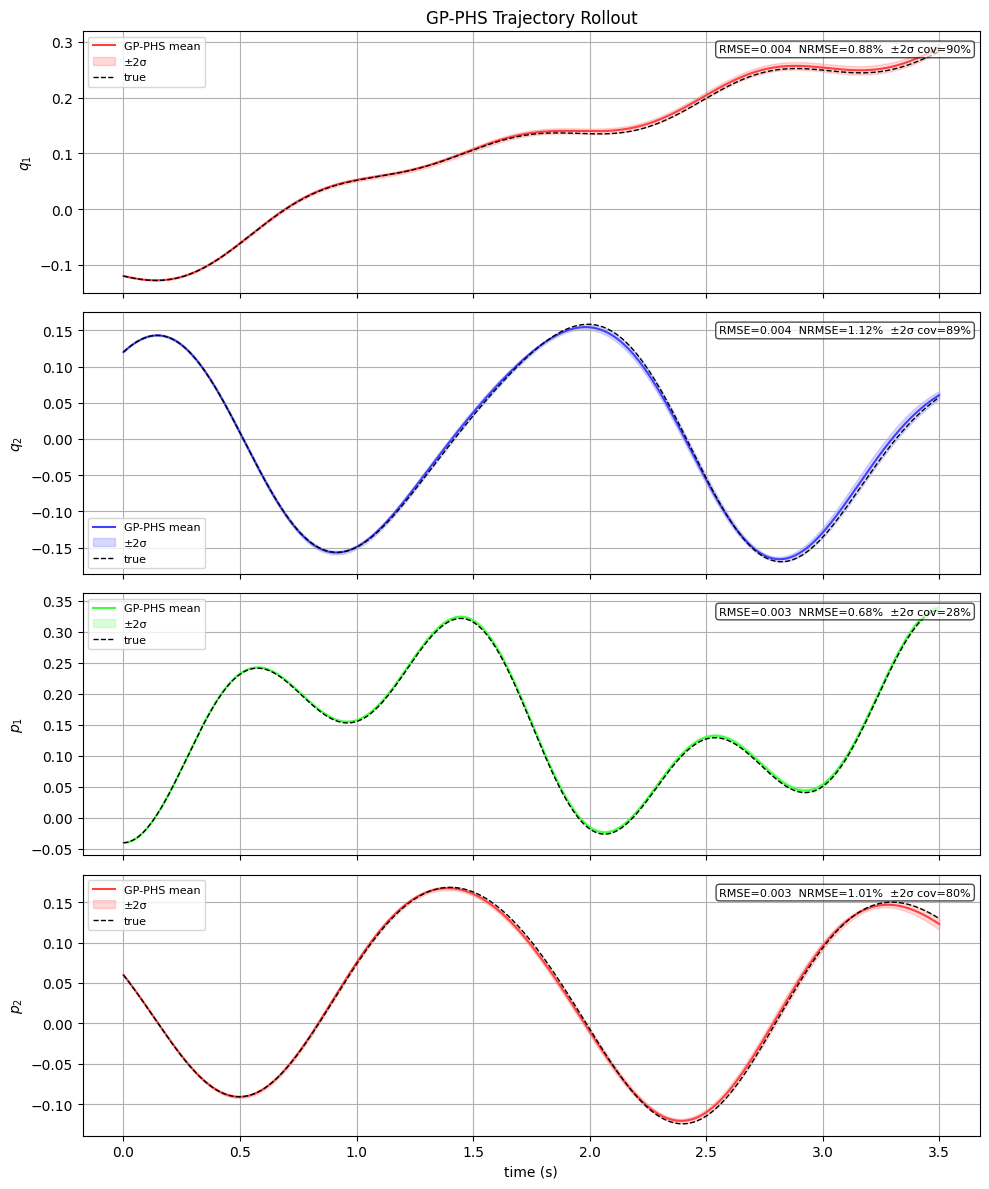

In [20]:
for i in range(len(X0_TEST)):
    plot.pltTrajectory(
        t_gp,
        mean[:, i, :],
        std=std[:, i, :],
        x_true=traj_sims[i],
        state_lbls=[r'$q_1$', r'$q_2$', r'$p_1$', r'$p_2$'],
        figname=f"traj_{i}",
    )